<h1>Nivel 1</h1>

<h3>1. 

- Importa como un DataFrame el archivo sprint10.xlsx. Asegúrate de que el archivo se importa correctamente, con los nombres de columnas que le corresponden, sin manipular el archivo original.

- Ordena el DataFrame por el país de origen. En caso de empate, ordena por el nombre de la ciudad.

- Muestra las primeras 10 filas.

Adicionalmente, realiza un print donde compruebe que el DNI sólo tiene valores únicos.</h3>

In [ ]:
# Instalacion de openpyxl
pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [134]:
# Importacion libreria pandas
import pandas as pd

# Lectura excel
df = pd.read_excel("sprint10.xlsx", skiprows=3)

# Limpieza cuadricula unnamed
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Ordenar dataframe por pais de origen de manera ascendente (a-z)
df = df.sort_values(by="País d'origen", ascending=True)

# Muestra de los 10 primeros registros
df.head(10)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
598,Laura,Schmidt,57692936L,Alemanya,Hamburg,3,5,1956,NC,1.828 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
383,Mia,Fischer,43756083N,Alemanya,Munic,8,9,1953,D,1.666 €,NaN,1.0,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
438,Laura,Schneider Müller,26634596X,Alemanya,Munic,28,11,1990,D,2.778 €,NaN,1.0,Grup D
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C


In [135]:
# Comprobacion columna DNI valores unicos
print(df["DNI"].is_unique)

True


<h3>2.

- Crea una columna que sea el nombre completo.

- Crea una columna si la persona ha nacido en España o no.

- Pon el DNI como índice del DataFrame (nombres de filas).

- Sustituye el nombre de las columnas Día de Nacimiento, Mes de Nacimiento y Año de Nacimiento por Día, Mes y Año.

- Sustituye a H por Hombre, D por Mujer, A por Otros y NC por un dato faltante (enano/null/na).

- Muestra todos los cambios que has realizado en una sola tabla.</h3>

In [136]:
# Union columnas nombre y apellido
df["Nombre_completo"] = df["Nom"] + ' ' + df["Cognoms"]
df = df[["Nombre_completo"] + [col for col in df.columns if col != "Nombre_completo"]]

# Eliminacion columnas nombre y apellido
df = df.drop(columns=["Nom", "Cognoms"])

# Columna nueva en funcion de si el usuario ha nacido en España o no
df.insert(3, "Nacido/a España",(df["País d'origen"] == "Espanya").map({True: "Sí", False: "No"}))

# Fitro para mostrar solo los usuarios de España
df = df[df["País d'origen"] == "Espanya"]

# Definir la columna DNI como index
df = df.set_index("DNI")

# Renombrar columnas Dia de Naixement por Dia, Mes de Naixement por Mes y Any de Naixement por Año
df = df.rename(columns={"Dia de Naixement": "Dia", "Mes de Naixement": "Mes", "Any de Naixement": "Año"})

# Renombrar los valores H por Hombre, D por Mujer, A por Otros y NC por null
df["Gènere"] = df["Gènere"].replace({"H": "Hombre", "D": "Mujer", "A": "Otros", "NC": "null"})

# visualizacion de todo lo anterior
df

,Nombre_completo,País d'origen,Nacido/a España,Ciutat,Dia,Mes,Año,Gènere,Salari mensual,Fills,No Fills,Grup Professional
DNI,,,,,,,,,,,,
41974885N,Arnau Ferrer Romero,Espanya,Sí,València,13,7,1958,Hombre,1.786 €,1.0,NaN,Grup B
19863880V,Carla López Romero,Espanya,Sí,Sevilla,22,4,1954,Mujer,1.173 €,1.0,NaN,Grup A
90464341H,Jordi Ferrer Martínez,Espanya,Sí,València,12,11,1981,Hombre,1.664 €,NaN,1.0,Grup A
54990944C,Laia Sánchez Romero,Espanya,Sí,Bilbao,4,12,1960,Mujer,2.060 €,1.0,NaN,Grup C
46129359E,Laia Castells Martínez,Espanya,Sí,Madrid,8,4,1975,Mujer,1.442 €,NaN,1.0,Grup B
...,...,...,...,...,...,...,...,...,...,...,...,...
37325572G,Carla López López,Espanya,Sí,Barcelona,7,3,1956,Mujer,812 €,1.0,NaN,Grup A
74165595P,Jordi Castells,Espanya,Sí,Bilbao,1,6,1953,Hombre,1.326 €,1.0,NaN,Grup A
94719538H,Carla Romero Ferrer,Espanya,Sí,Sevilla,28,5,1991,Mujer,730 €,NaN,1.0,Grup A


<h3>3.
Junta las columnas Hijos y No Hijos en una sola columna, utilizando el método .apply() y definiendo una función que resuelva el problema. La columna nueva debe llamarse "Hijos" y tomar los valores "Sí" o "No".</h3>

In [137]:
# Funcion para verificar si el usuatio tiene hijos o no
def tiene_hijos(fila):
    if fila["Fills"] == 1.0:
        return "Sí"
    else:
        return "No"

# Se aplica la funcion a la columna Hijos con aplly
df["Hijos"] = df.apply(tiene_hijos, axis=1)

# Eliminacion de las columnas fills y no fills
df = df.drop(columns=["Fills", "No Fills"])

# Visualización de lo anterior
df

,Nombre_completo,País d'origen,Nacido/a España,Ciutat,Dia,Mes,Año,Gènere,Salari mensual,Grup Professional,Hijos
DNI,,,,,,,,,,,
41974885N,Arnau Ferrer Romero,Espanya,Sí,València,13,7,1958,Hombre,1.786 €,Grup B,Sí
19863880V,Carla López Romero,Espanya,Sí,Sevilla,22,4,1954,Mujer,1.173 €,Grup A,Sí
90464341H,Jordi Ferrer Martínez,Espanya,Sí,València,12,11,1981,Hombre,1.664 €,Grup A,No
54990944C,Laia Sánchez Romero,Espanya,Sí,Bilbao,4,12,1960,Mujer,2.060 €,Grup C,Sí
46129359E,Laia Castells Martínez,Espanya,Sí,Madrid,8,4,1975,Mujer,1.442 €,Grup B,No
...,...,...,...,...,...,...,...,...,...,...,...
37325572G,Carla López López,Espanya,Sí,Barcelona,7,3,1956,Mujer,812 €,Grup A,Sí
74165595P,Jordi Castells,Espanya,Sí,Bilbao,1,6,1953,Hombre,1.326 €,Grup A,Sí
94719538H,Carla Romero Ferrer,Espanya,Sí,Sevilla,28,5,1991,Mujer,730 €,Grup A,No


<h3>4. Crea una tabla resumen que permita ver el sueldo medio, medio, mínimo y máximo por Género. Ordena la tabla en función del sueldo medio.</h3>

In [138]:
# Renombramiento de la columna salari mensual por salari mensual €
df.rename(columns={"Salari mensual": "Salari mensual €"}, inplace= True)

# Se elimina todo lo que no sea numeros y se convierte a float
df["Salari mensual €"] = (df["Salari mensual €"].str.replace(".", "", regex=False).str.replace(",", "", regex=False).str.replace("€", "", regex=False).astype(float))

# Guardado del resumen con la media, mediana, minimo y maximo de salari mensual agrupado por genero
resumen = df.groupby("Gènere")["Salari mensual €"].agg(Media = "mean", Mediana = "median", Minimo = "min", Maximo = "max")

# Se ordena el resumen por la media y se redondea a 2 decimales
resumen = resumen.sort_values(by="Media", ascending=False)
resumen = resumen.round(2)

# Visualización del resumen
resumen

,Media,Mediana,Minimo,Maximo
Gènere,,,,
Otros,1706.18,1684.5,703.0,3175.0
Hombre,1682.11,1563.0,742.0,3356.0
null,1597.14,1437.0,776.0,2969.0
Mujer,1460.16,1339.0,665.0,3021.0


<h3> 5.

- Crea una tabla resumen con el salario medio por género (filas) y país de origen (columnas).

- Añade las medias a los márgenes de la tabla.

(EXTRA): Aplica formato condicional en la tabla para ver en un color más intenso los valores más elevados.</h3> 

In [ ]:
# Instslacion de jinja2
pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp311-cp311-win_amd64.whl (15 kB)

   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Instalacion de matplotlib
pip install matplotlib

  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------- ----------------------------- 1.8/7.1 MB 25.0 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 24.2 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-no

<h3> Tabla resumen de Eapaña </h3>

In [139]:
# Generacion de la tabla resumen a traves de pivot_table, con los valores de salari mensual, 
# las filas con el genero, las columnas con el pais de origen, la media como margenes
tabla_resumen = df.pivot_table(
    values="Salari mensual €", 
    index="Gènere", 
    columns="País d'origen", 
    aggfunc="mean",
    margins=True,
    margins_name="Media")

# Aplicacion de formato condicional con background_gradient con el mapa de colores Yelow, 
# Orange, Red
tabla_resumen.style.background_gradient(cmap="YlOrRd").format("{:.2f}")


País d'origen,Espanya,Media
Gènere,,
Hombre,1682.11,1682.11
Mujer,1460.16,1460.16
Otros,1706.18,1706.18
null,1597.14,1597.14
Media,1582.16,1582.16


<h3> Tabla resumen de todos los paises </h3>

In [140]:
import pandas as pd

def tiene_hijos(fila):
    if fila["Fills"] == 1.0:
        return "Sí"
    else:
        return "No"

df = pd.read_excel("sprint10.xlsx", skiprows=3)
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
df = df.sort_values(by="País d'origen", ascending=True)
df["Nombre_completo"] = df["Nom"] + ' ' + df["Cognoms"]

df = df[["Nombre_completo"] + [col for col in df.columns if col != "Nombre_completo"]]

df = df.drop(columns=["Nom", "Cognoms"])
df = df.rename(columns={"Dia de Naixement": "Dia", "Mes de Naixement": "Mes", "Any de Naixement": "Año"})

df["Gènere"] = df["Gènere"].replace({"H": "Hombre", "D": "Mujer", "A": "Otros", "NC": "null"})

df["Hijos"] = df.apply(tiene_hijos, axis=1)

df.rename(columns={"Salari mensual": "Salari mensual €"}, inplace= True)

df["Salari mensual €"] = (df["Salari mensual €"].str.replace(".", "", regex=False).str.replace(",", "", regex=False).str.replace("€", "", regex=False).astype(float))

df = df.drop(columns=["Fills", "No Fills"])
tabla_resumen = df.pivot_table(
    values="Salari mensual €", 
    index="Gènere", 
    columns="País d'origen", 
    aggfunc="mean",
    margins=True,
    margins_name="Media")

tabla_resumen.style.background_gradient(cmap="YlOrRd").format("{:.2f}")

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Media
Gènere,,,,,,,,,,,
Hombre,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Mujer,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Otros,951.00,1141.00,1030.00,1706.18,nan,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
null,1931.50,1135.67,1252.00,1597.14,1573.00,1316.00,1365.50,1583.00,1553.50,1758.00,1568.87
Media,1858.35,1431.68,1489.13,1582.16,1465.36,1421.17,1441.69,1559.08,1527.23,1448.33,1561.46


<h3> 6.

- Crea una nueva columna que sea la fecha de nacimiento en formato Datetime a partir de las columnas día, mes y año. Utilizando esta columna crea una función que dada una fecha, te calcule la edad actual a día de hoy.
- Utiliza la función que acabas de crear para generar una columna nueva en DataFrame con la edad actual.</h3>

In [141]:
import pandas as pd
from datetime import datetime

# Funcion para poner si o no en funcion de si el usuario tiene hijos o no
def tiene_hijos(fila):
    if fila["Fills"] == 1.0:
        return "Sí"
    else:
        return "No"

# Funcion para calcular la edad con la fecha actual y la fecha de nacimiento
def calcular_edad(fecha_nacimiento):
    hoy = datetime.now()
    edad = hoy.year - fecha_nacimiento.year
    
    if (hoy.month, hoy.day) < (fecha_nacimiento.month, fecha_nacimiento.day):
        edad -= 1
    return edad

df = pd.read_excel("sprint10.xlsx", skiprows=3)

df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

df = df.sort_values(by="País d'origen", ascending=True)

df["Nombre_completo"] = df["Nom"] + ' ' + df["Cognoms"]
df = df[["Nombre_completo"] + [col for col in df.columns if col != "Nombre_completo"]]
df = df.drop(columns=["Nom", "Cognoms"])

df = df.rename(columns={"Dia de Naixement": "Dia", "Mes de Naixement": "Mes", "Any de Naixement": "Año"})

df["Gènere"] = df["Gènere"].replace({"H": "Hombre", "D": "Mujer", "A": "Otros", "NC": "null"})

# Aplicacion de la funcion tiene_hijos a la columna Hijos
df["Hijos"] = df.apply(tiene_hijos, axis=1)
df = df.drop(columns=["Fills", "No Fills"])

df.rename(columns={"Salari mensual": "Salari mensual €"}, inplace= True)
df["Salari mensual €"] = (df["Salari mensual €"].str.replace(".", "", regex=False).str.replace(",", "", regex=False).str.replace("€", "", regex=False).astype(float))

# Columna nueva fcha nacimiento
df["Fecha_nacimiento"] = pd.to_datetime({'year': df["Año"], 'month': df["Mes"], 'day': df["Dia"]}, errors='coerce')
df = df.drop(columns=["Dia", "Mes", "Año"])

# Aplicacion de la funcion clacular_edad a la columna edad actual
df["Edad_actual"] = df["Fecha_nacimiento"].apply(calcular_edad)

# Visualizacion de todo lo anterior 
df

,Nombre_completo,DNI,País d'origen,Ciutat,Gènere,Salari mensual €,Grup Professional,Hijos,Fecha_nacimiento,Edad_actual
21,Mia Schneider Fischer,28973553Z,Alemanya,Berlín,Otros,951.0,Grup A,No,1976-10-22,49
871,Lea Fischer,14773153R,Alemanya,Berlín,Mujer,1370.0,Grup A,Sí,1986-09-09,39
598,Laura Schmidt,57692936L,Alemanya,Hamburg,null,1828.0,Grup B,Sí,1956-05-03,69
602,Jonas Schneider,44060014R,Alemanya,Berlín,Hombre,2754.0,Grup D,Sí,1985-11-22,40
383,Mia Fischer,43756083N,Alemanya,Munic,Mujer,1666.0,Grup B,No,1953-09-08,72
...,...,...,...,...,...,...,...,...,...,...
222,Sophie Smith,86350703G,Regne Unit,Manchester,Mujer,1254.0,Grup B,Sí,1957-01-08,69
978,William Taylor,14371347B,Regne Unit,Londres,Hombre,1017.0,Grup A,No,1957-10-11,68
305,George Taylor Taylor,15056420W,Regne Unit,Londres,Hombre,1135.0,Grup A,Sí,1965-09-08,60
930,Sophie Brown,74953524F,Regne Unit,Londres,Mujer,2189.0,Grup C,Sí,1983-05-17,42


<h1> Nivel 2</h1>
<h3>1.

- Utilizando el siguiente DataFrame, adjunta la columna "Incremento" al dataframe del nivel anterior.

- Actualiza la columna salario en función de los porcentajes que se adjuntan. No modifiques manualmente los incrementos, escribe código Python para realizar las conversiones necesarias.

df_increment = pd.DataFrame({"Grupo":["Grupo A","Grupo B","Grupo C", "Grupo D" ] , "Incremento":["5%","3,5%","2%","8%"]})</h3>

![ejemplo ejercicio 1 nivel 2.png](dfincremento.png)

In [142]:
import pandas as pd
from datetime import datetime

# Funcion para poner si o no en funcion de si el usuario tiene hijos o no
df["Gènere"] = df["Gènere"].replace({"H": "Hombre", "D": "Mujer", "A": "Otros", "NC": "null"})
def tiene_hijos(fila):
    if fila["Fills"] == 1.0:
        return "Sí"
    else:
        return "No"

# Funcion para calcular la edad con la fecha actual y la fecha de nacimiento
def calcular_edad(fecha_nacimiento):
    hoy = datetime.now()
    edad = hoy.year - fecha_nacimiento.year
    
    if (hoy.month, hoy.day) < (fecha_nacimiento.month, fecha_nacimiento.day):
        edad -= 1
    return edad

df = pd.read_excel("sprint10.xlsx", skiprows=3)

df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

df = df.sort_values(by="País d'origen", ascending=True)

df["Nombre_completo"] = df["Nom"] + ' ' + df["Cognoms"]
df = df[["Nombre_completo"] + [col for col in df.columns if col != "Nombre_completo"]]
df = df.drop(columns=["Nom", "Cognoms"])

df = df.rename(columns={"Dia de Naixement": "Dia", "Mes de Naixement": "Mes", "Any de Naixement": "Año"})

# Aplicacion de la funcion tiene_hijos a la columna Hijos
df["Hijos"] = df.apply(tiene_hijos, axis=1)
df = df.drop(columns=["Fills", "No Fills"])

df.rename(columns={"Salari mensual": "Salari mensual €"}, inplace= True)
df["Salari mensual €"] = (df["Salari mensual €"].str.replace(".", "", regex=False).str.replace(",", "", regex=False).str.replace("€", "", regex=False).astype(float))

# Columna nueva fcha nacimiento
df["Fecha_nacimiento"] = pd.to_datetime({'year': df["Año"], 'month': df["Mes"], 'day': df["Dia"]}, errors='coerce')
df = df.drop(columns=["Dia", "Mes", "Año"])

# Aplicacion de la funcion clacular_edad a la columna edad actual
df["Edad_actual"] = df["Fecha_nacimiento"].apply(calcular_edad)

# Dataframe incremento
df_increment = pd.DataFrame({"Grupo":["Grupo A","Grupo B","Grupo C", "Grupo D" ] , "Incremento":["5%","3,5%","2%","8%"]})
df_increment.rename(columns={'Grupo': 'Grup Professional', 'Incremento': 'Incremento_%'}, inplace=True)
df_increment["Incremento_%"] = df_increment["Incremento_%"].str.replace("%", "").str.replace(",", ".").astype(float) / 100
df_increment["Grup Professional"] = df_increment["Grup Professional"].str.replace("Grupo", "Grup")

# Union dataframes
df = df.merge(df_increment, on= "Grup Professional")
df["Salari mensual €"] = df["Salari mensual €"] * (1 + df["Incremento_%"])

# Visualizacion dataframes unidos
df


,Nombre_completo,DNI,País d'origen,Ciutat,Gènere,Salari mensual €,Grup Professional,Hijos,Fecha_nacimiento,Edad_actual,Incremento_%
0,Mia Schneider Fischer,28973553Z,Alemanya,Berlín,A,998.55,Grup A,No,1976-10-22,49,0.050
1,Lea Fischer,14773153R,Alemanya,Berlín,D,1438.50,Grup A,Sí,1986-09-09,39,0.050
2,Laura Schmidt,57692936L,Alemanya,Hamburg,NC,1891.98,Grup B,Sí,1956-05-03,69,0.035
3,Jonas Schneider,44060014R,Alemanya,Berlín,H,2974.32,Grup D,Sí,1985-11-22,40,0.080
4,Mia Fischer,43756083N,Alemanya,Munic,D,1724.31,Grup B,No,1953-09-08,72,0.035
...,...,...,...,...,...,...,...,...,...,...,...
995,Sophie Smith,86350703G,Regne Unit,Manchester,D,1297.89,Grup B,Sí,1957-01-08,69,0.035
996,William Taylor,14371347B,Regne Unit,Londres,H,1067.85,Grup A,No,1957-10-11,68,0.050
997,George Taylor Taylor,15056420W,Regne Unit,Londres,H,1191.75,Grup A,Sí,1965-09-08,60,0.050
998,Sophie Brown,74953524F,Regne Unit,Londres,D,2232.78,Grup C,Sí,1983-05-17,42,0.020


<h3> 2.

Utilizando un bucle, exporta en 4 archivos (formato .xlsx o .csv) los datos de cada Grupo Profesional.

Por ejemplo: "datos_GrupA.xlsx" , "datos_GrupB.xlsx" ...

Exporta un 5º DataFrame en formato .xlsx o .csv que contenga cuántos trabajadores hay por cada Grupo Profesional, cuál es su sueldo medio y cuál es su edad media.</h3>

In [143]:
# Definicion lista grupos para bucle for
lista_grupos = ["Grup A", "Grup B", "Grup C", "Grup D"]

# Bucle for para seleccionar los grupos profesionales, crear el nombre del archivo y convertir
# a csv cada conjunto de grupo profesional
for grupo in lista_grupos:
    df_grupo_profesional = df[df["Grup Professional"] == grupo]
    nombre_grupo_junto = grupo.replace(" ", "") 
    nombre_archivo = f"datos_{nombre_grupo_junto}.csv"
    df_grupo_profesional.to_csv(nombre_archivo, index= False, encoding="utf-8", sep=";")

# Resumen y exportacion a csv del conteo de trabajadores por grupo profesional, 
# sueldos medios por grupo profesional y edad media por grupo profesional
df_resumido = df.groupby("Grup Professional").agg(trabajadores = ("DNI", "count"), sueldo_medio_euros = ("Salari mensual €", "mean"), edad_media = ("Edad_actual", "mean"))  
df_resumido = df_resumido.round(2)
df_resumido.to_csv("resumen_grupos.csv", encoding="utf-8", sep=";")

# Visualizacion resumen grupos profesionales
df_resumido

,trabajadores,sueldo_medio_euros,edad_media
Grup Professional,,,
Grup A,490,1213.32,49.29
Grup B,318,1724.55,48.04
Grup C,137,2289.19,51.08
Grup D,55,3100.82,45.20


<h1> Nivel 3</h1>
<h3>El nivel 3 de este sprint es totalmente diferente a otros sprints que has hecho hasta ahora, ya que son ejercicios más abstractos que requieren pelearse bastante. No siguen con el mismo dataset de los niveles anteriores, sino que te plantean dos situaciones nuevas totalmente distintas entre sí.<h3>

<h3> 1.
Crea una función que tome un dataframe como parámetro de entrada.

La función debe crear (y exportar) un gráfico automáticamente para cada columna del dataframe. Por ejemplo:

- un histograma/boxplot si la variable es numérica
- unas barras de los valores más frecuentes si es categórica
- unas barras de los años más frecuentes si el dato está en formato fecha.
- La idea es crear una función que funcione por cualquier dataframe, no sólo con lo que hemos trabajado hasta ahora.

Muestra el resultado de la función en alguno de los datasets de ejemplo que contiene el paquete seaborn. Por ejemplo, iris , penguins o titanic .

Ten en consideración que en el siguiente sprint trabajarás exclusivamente con gráficos. El objetivo de este ejercicio no es crear gráficos muy elaborados, sino resolver una necesidad de forma rápida y automática.</h3>

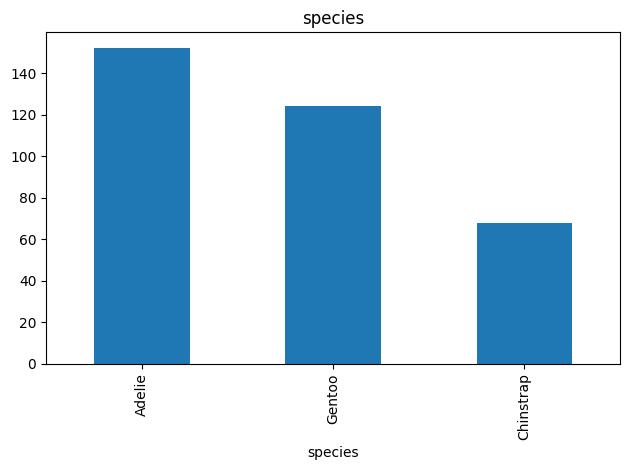

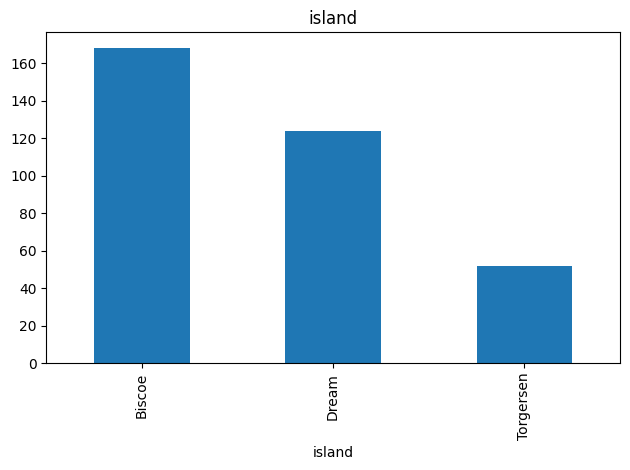

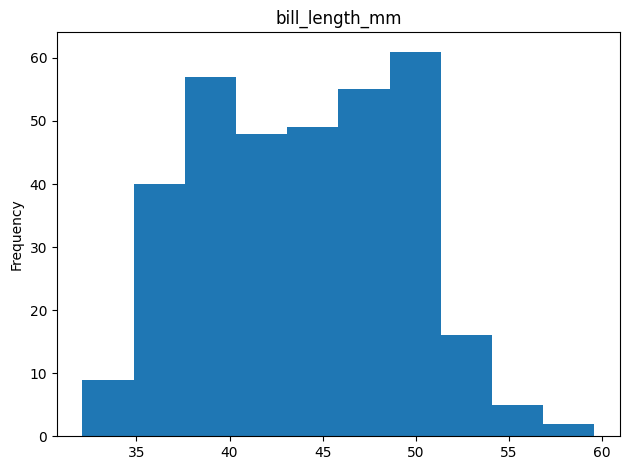

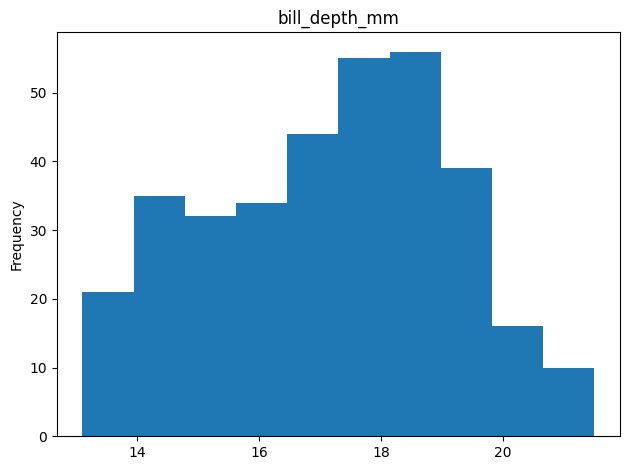

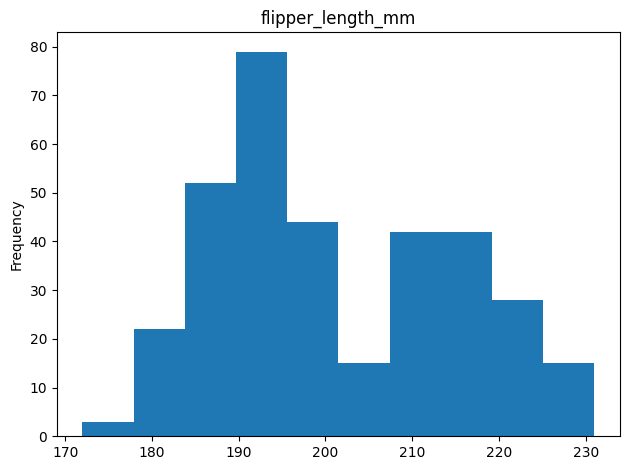

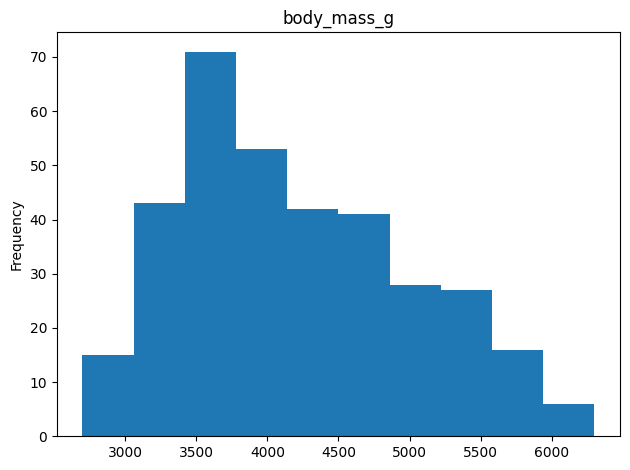

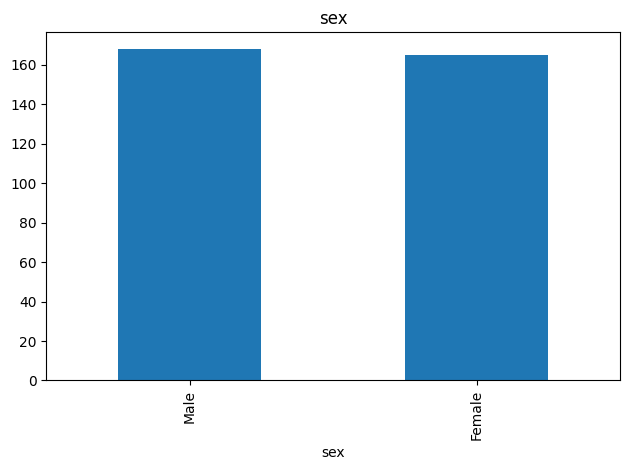

In [ ]:
# Importacion librerias necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Datasts penguins de seaborn
df = sns.load_dataset("penguins")

# Funcion con bucle for que recorre cada columna del dataframe y valora si es numerica 
# o categorica, en funcion de lo que se cumpla se crea un grafico u otro adecuado al tipo
# de dato y se guarda una imagen de cada grafico
def crear_grafico(df):
    for columna in df.columns:                    
        
        if pd.api.types.is_numeric_dtype(df[columna]):        
            df[columna].plot.hist(title=columna)
            
        elif pd.api.types.is_datetime64_any_dtype(df[columna]):  
            df[columna].dt.year.value_counts().sort_index().plot.bar(title=columna)
            
        else:                                                  
            df[columna].value_counts().plot.bar(title=columna)
        
        plt.tight_layout()
        plt.savefig(f"grafico_{columna}.png")   
        plt.show()                               
        plt.close()                              

# LLamada a la funcion para crear los graficos y guardarlos
crear_grafico(df)


<h3> 2.

Carga el archivo matriz_distancies.xlsx en pandas, de modo que los nombres de filas y los nombres de columnas sean los de las ciudades. Borra "Las Palmas de Gran Canaria" y "Palma" para que podamos realizar el trayecto en coche.

Fuente: <a href="https://espana.mejoresrutas.com/tabla-de-distancias/es/">Mejores Rutas</a>

Nos interesa visitar todas las principales ciudades de España recorriendo la mínima distancia posible.

<b> No hace falta que lo hagas de forma óptima, nos interesa que desarrolles una solución razonable utilizando las herramientas que tienes actualmente. </b>

Por ejemplo, una aproximación sencilla (que no óptima) sería yendo siempre a la ciudad más cercana que no hayamos visitado todavía

Haz una función que dada la matriz de distancias y la ciudad de origen, haga una propuesta de ruta que sea lo más corta posible que puedas, devolviendo una lista con el orden de visita. Da también la distancia total recorrida.

(EXTRA) Desde qué ciudad la ruta sería más corta con el algoritmo planteado </h3>

In [144]:
# Importacion librerias necesarias
import pandas as pd
import unicodedata
import string

# Funcion para normalizar el texto, limpieza de mayusculas, signos de puntuacion, espacios
# en blanco, caracteres especiales, etc
def normalizar(texto):
    # Poner palabras minúsculas
    texto = texto.lower()
    
    # Quitar tildes a todas las palabras 
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    
    # Quitar espacios a todas las palabras
    texto = texto.replace(" ", "")
    
    # Quitar puntuación a todas las palabras
    texto = ''.join(c for c in texto if c not in string.punctuation)
    
    return texto

# Funcion que propone la mejor ruta
def propuesta_ruta(df, ciudad_origen):

    # Lista de todas las ciudades
    ciudades = list(df.index)              
    ciudad_actual = ciudad_origen
    # Empieza la ruta con la ciudad origen y la distancia total en 0
    ruta = [ciudad_actual]                 
    distancia_total = 0
    
    # Ciudades que aún no hemos visitado
    pendientes = [c for c in ciudades if c != ciudad_actual]
    
    while pendientes:
        # Se obtiene las distancias desde la ciudad actual a las pendientes
        distancias = df.loc[ciudad_actual, pendientes]
        
        # Se encuentra la ciudad más cercana
        ciudad_mas_cercana = distancias.idxmin()
        distancia_minima = distancias.min()
        
        # Se acumula la distancia y se avanza
        distancia_total += distancia_minima
        ruta.append(ciudad_mas_cercana)
        pendientes.remove(ciudad_mas_cercana)
        ciudad_actual = ciudad_mas_cercana
    
    return ruta, distancia_total

# Carga xlsx matriz distancias
df = pd.read_excel("matriu_distancies.xlsx", index_col=0)

# Borrado columnas y filas Palma/Las Palmas de Gran Canaria
df.drop(columns=["Palma", "Las Palmas de Gran Canaria"], inplace=True)
df.drop(["Palma", "Las Palmas de Gran Canaria"], inplace=True)

# Extraccion nombres ciudades
lista_ciudades = list(df.columns)

# Lista que se muestra en el input para poder seleccionar una ciudad de origen
lista_ciudades_limpia = ', '.join(map(str, lista_ciudades))

# Diccionario para tener la lista normalizada y poder desnormalizarla cuando sea necesario
diccionario_normalizacion = {normalizar(c): c for c in lista_ciudades}

# Bucle para introducir la ciudad de origen y verificar que el dato es correcto
while True:
    ciudad_origen = input(f"Introduce una de las siguientes ciudades origen para calcular el trayecto: {lista_ciudades_limpia}")
    ciudad_origen_normalizada = normalizar(ciudad_origen)

    if ciudad_origen_normalizada in diccionario_normalizacion:
        break
    else:
        print("Selecciona una ciudad de la lista")

# Recuperar el nombre original de la ciudad
ciudad_original = diccionario_normalizacion[ciudad_origen_normalizada]

# Calcular la ruta
ruta, distancia = propuesta_ruta(df, ciudad_original)

# Mostrar resultados
print(f"\nRuta propuesta desde {ciudad_original}:")
for i, ciudad in enumerate(ruta):
    print(f"  {i+1}. {ciudad}")
print(f"\nDistancia total recorrida: {distancia} km")

# Muestra cual es la mejor ciudad y la mejor distancia de toda la matriz
mejor_ciudad = None
mejor_distancia = float('inf')
for ciudad in df.index:
    ruta_temp, distancia_temp = propuesta_ruta(df, ciudad)
    if distancia_temp < mejor_distancia:
        mejor_distancia = distancia_temp
        mejor_ciudad = ciudad
print(f"\nLa mejor ciudad de origen es: {mejor_ciudad}")
print(f"Con una distancia total de: {mejor_distancia} km")


Ruta propuesta desde Barcelona:
  1. Barcelona
  2. Hospitalet de Llobregat
  3. Zaragoza
  4. Valencia
  5. Alicante
  6. Murcia
  7. Córdoba
  8. Sevilla
  9. Málaga
  10. Valladolid
  11. Gijón
  12. Bilbao
  13. Vigo

Distancia total recorrida: 2778.0 km

La mejor ciudad de origen es: Barcelona
Con una distancia total de: 2778.0 km
